In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

In [3]:
fs = 1000
t = np.arange(0, 5, 1/fs)

# Physiological component
physio = (
    1.0 * np.sin(2*np.pi*20*t)
    + 0.5 * np.sin(2*np.pi*40*t)
    + 0.3 * np.sin(2*np.pi*80*t)
)

# 60 Hz power-line interference
line_noise = 0.7 * np.sin(2*np.pi*60*t)

# Low-frequency baseline drift
baseline = 0.5 * np.sin(2*np.pi*0.5*t)

# High-frequency noise
np.random.seed(42)
high_freq_noise = 0.2 * np.random.randn(len(t))

# Measured signal
x = physio + line_noise + baseline + high_freq_noise

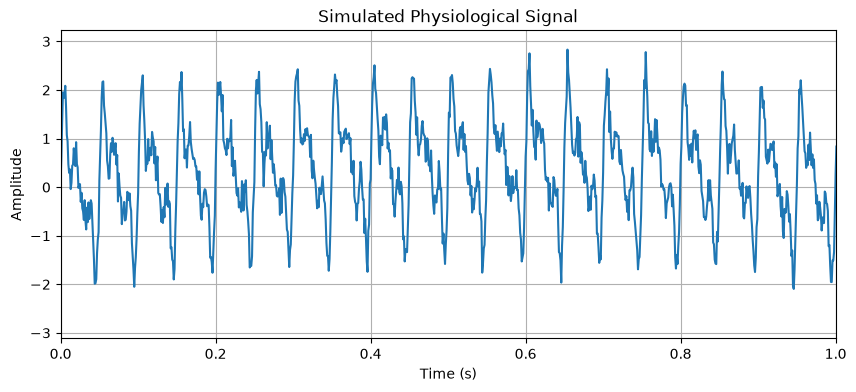

In [4]:
plt.figure(figsize=(10, 4))
plt.plot(t, x)
plt.xlim(0, 1)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Simulated Physiological Signal")
plt.grid()
plt.show()

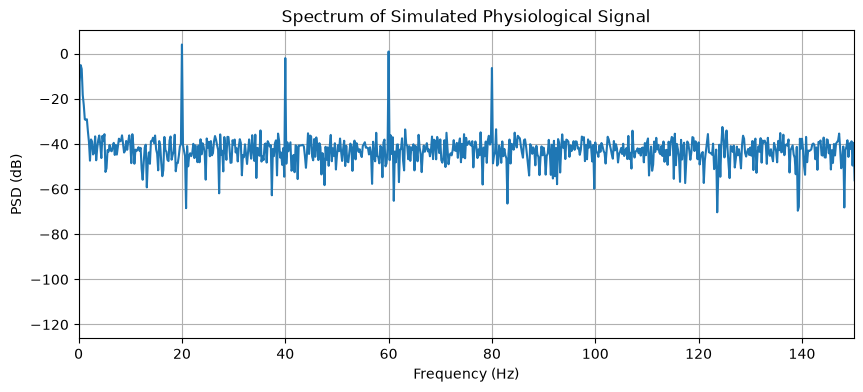

In [5]:
f , X = signal.periodogram(x, fs=fs)
plt.figure(figsize=(10, 4))
plt.plot(f, 10*np.log10(np.maximum(X, 1e-12)))
plt.xlim(0, 150)
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (dB)")
plt.title("Spectrum of Simulated Physiological Signal")
plt.grid()
plt.show()

In [6]:
#bandpass

lowcut = 10
highcut = 100
order =4

b_band, a_band = signal.butter(
    order,
    [lowcut, highcut],
    btype = 'bandpass',
    fs=fs
)

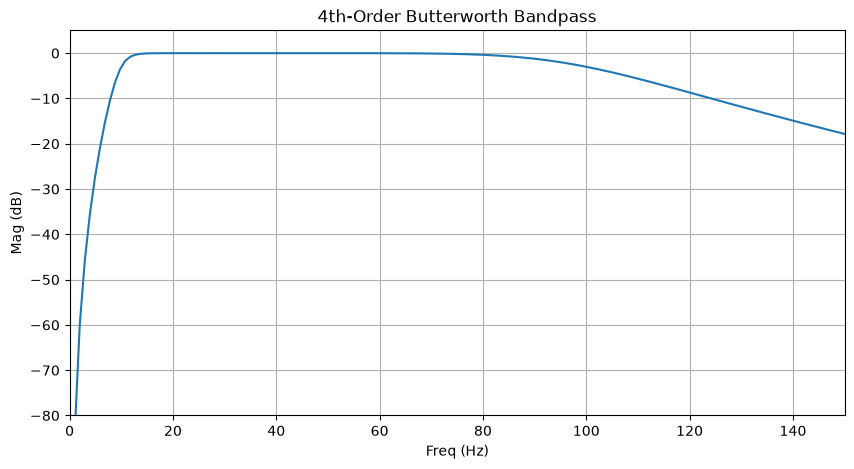

In [7]:
f_band, h_band = signal.freqz(b_band, a_band, fs=fs)

plt.figure(figsize=(10,5))
plt.plot(f_band , 20*np.log10(np.abs(h_band)))
plt.xlim(0,150)
plt.ylim(-80,5)
plt.title("4th-Order Butterworth Bandpass")
plt.xlabel("Freq (Hz)")
plt.ylabel("Mag (dB)")
plt.grid()
plt.show()

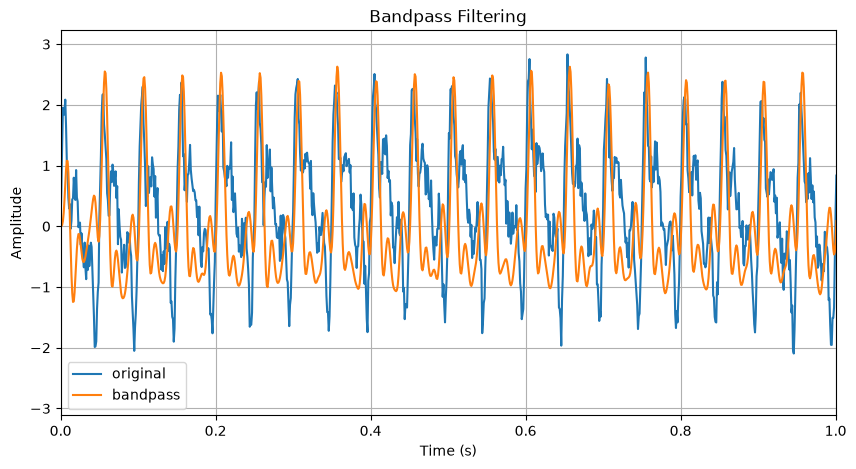

In [8]:
y_bp = signal.lfilter(b_band, a_band, x)
plt.figure(figsize=(10,5))
plt.plot(t, x, label = "original")
plt.plot(t, y_bp, label = "bandpass")
plt.xlim(0, 1)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Bandpass Filtering")
plt.legend()
plt.grid()
plt.show()

In [9]:
b_notch, a_notch = signal.iirnotch(
    60,
    Q=30,
    fs=fs
)

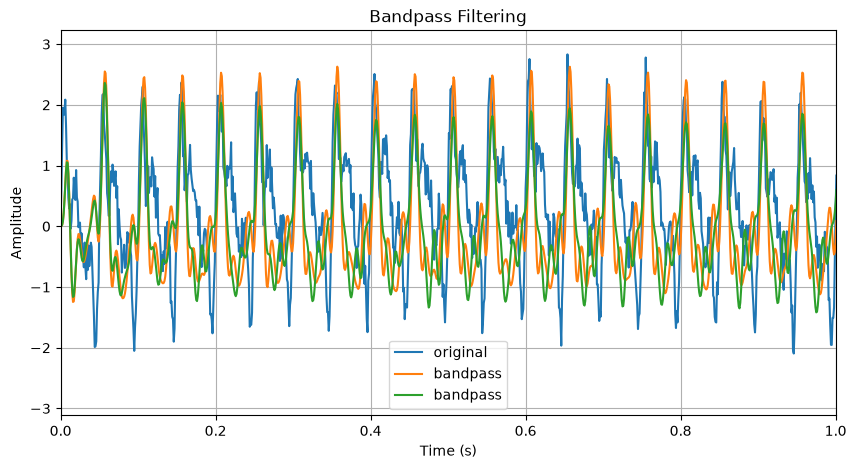

In [10]:
y_final = signal.lfilter(b_notch, a_notch, y_bp)
plt.figure(figsize=(10,5))
plt.plot(t, x, label = "original")
plt.plot(t, y_bp, label = "bandpass")
plt.plot(t, y_final, label = "bandpass")
plt.xlim(0, 1)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Bandpass Filtering")
plt.legend()
plt.grid()
plt.show()

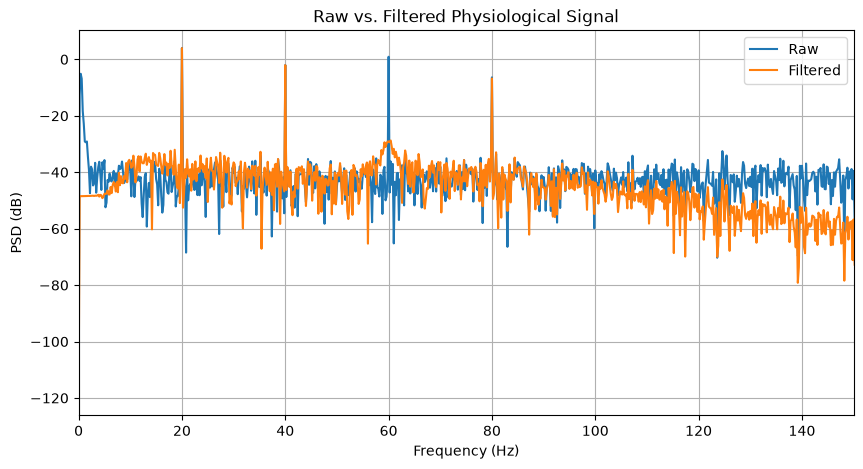

In [11]:
f_raw, X_raw = signal.periodogram(x, fs=fs)
f_final, X_final = signal.periodogram(y_final, fs=fs)

plt.figure(figsize=(10, 5))

plt.plot(
    f_raw,
    10*np.log10(np.maximum(X_raw, 1e-12)),
    label="Raw"
)

plt.plot(
    f_final,
    10*np.log10(np.maximum(X_final, 1e-12)),
    label="Filtered"
)

plt.xlim(0, 150)
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (dB)")
plt.title("Raw vs. Filtered Physiological Signal")
plt.legend()
plt.grid()
plt.show()

In [12]:
idx5 = np.argmin(np.abs(f_raw - 5))
idx20 = np.argmin(np.abs(f_raw - 20))
idx40 = np.argmin(np.abs(f_raw - 40))
idx60 = np.argmin(np.abs(f_raw - 60))
idx80 = np.argmin(np.abs(f_raw - 80))

atten5 = 10 * np.log10(X_final[idx5] / X_raw[idx5])
atten20 = 10 * np.log10(X_final[idx20] / X_raw[idx20])
atten40 = 10 * np.log10(X_final[idx40] / X_raw[idx40])
atten60 = 10 * np.log10(X_final[idx60] / X_raw[idx60])
atten80 = 10 * np.log10(X_final[idx80] / X_raw[idx80])

print(f"5 Hz: {atten5:.2f} dB")
print(f"20 Hz: {atten20:.2f} dB")
print(f"40 Hz: {atten40:.2f} dB")
print(f"60 Hz: {atten60:.2f} dB")
print(f"80 Hz: {atten80:.2f} dB")

5 Hz: -11.96 dB
20 Hz: -0.04 dB
40 Hz: -0.05 dB
60 Hz: -29.99 dB
80 Hz: -0.39 dB


In [13]:
fs = 1000
t = np.arange(0, 1, 1/fs)

event = np.exp(-0.5 * ((t-0.5)/ 0.01)**2)

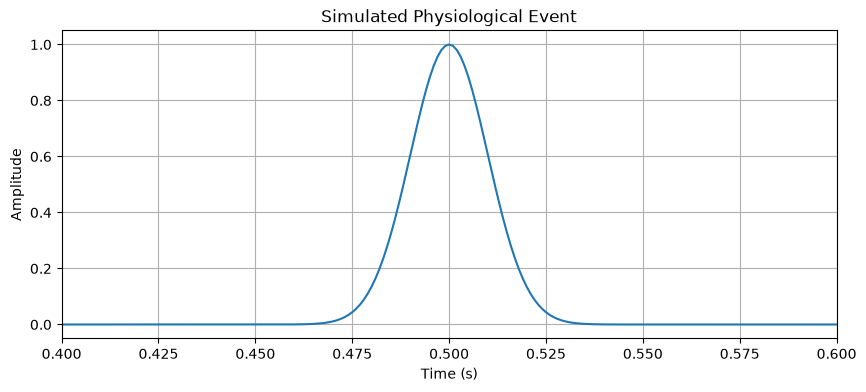

In [14]:
plt.figure(figsize=(10, 4))
plt.plot(t, event)
plt.xlim(0.4, 0.6)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Simulated Physiological Event")
plt.grid()
plt.show()

In [15]:
np.random.seed(42)

noise = 0.2 * np.random.randn(len(t))

event_noisy = event + noise

In [16]:
event_filtered = signal.lfilter(
    b_band,
    a_band,
    event_noisy
)

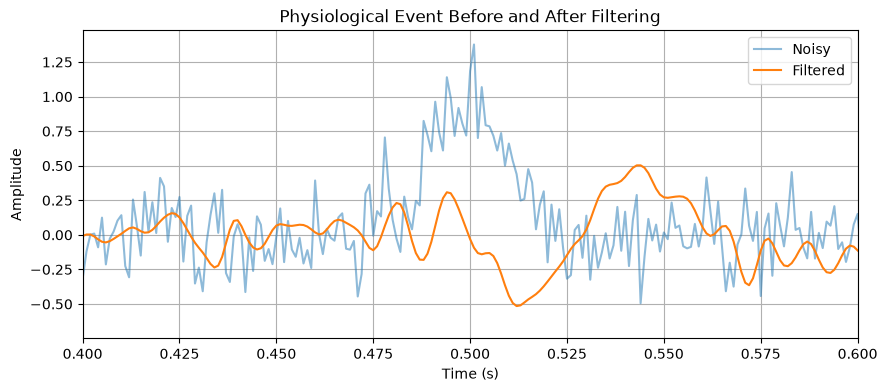

In [17]:
plt.figure(figsize=(10, 4))

plt.plot(t, event_noisy, alpha=0.5, label="Noisy")
plt.plot(t, event_filtered, label="Filtered")

plt.xlim(0.4, 0.6)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Physiological Event Before and After Filtering")
plt.legend()
plt.grid()
plt.show()

In [18]:
peak_original = np.argmax(event)
peak_filtered = np.argmax(event_filtered)

t_original = peak_original / fs
t_filtered = peak_filtered / fs

timing_error_ms = (t_filtered - t_original) * 1000

print(f"Original peak: {t_original*1000:.2f} ms")
print(f"Filtered peak: {t_filtered*1000:.2f} ms")
print(f"Timing error: {timing_error_ms:.2f} ms")

Original peak: 500.00 ms
Filtered peak: 544.00 ms
Timing error: 44.00 ms


In [19]:
event_zero = signal.filtfilt(
    b_band,
    a_band,
    event_noisy
)
peak_zero = np.argmax(event_zero)
t_zero = peak_zero / fs

print(f"Zero-phase peak: {t_zero*1000:.2f} ms")

Zero-phase peak: 501.00 ms


C:\Users\ryguy\AppData\Local\Temp\ipykernel_24708\1351627825.py:1: UserWarning: The filter's denominator is extremely small at frequencies [0.000, 0.006, 0.012], around which a singularity may be present
  f_gd, gd = signal.group_delay(


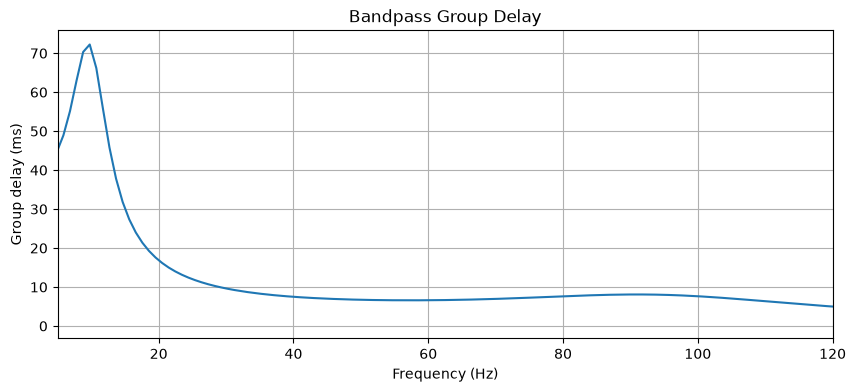

In [20]:
f_gd, gd = signal.group_delay(
(b_band, a_band),
fs=fs
)

plt.figure(figsize=(10, 4))
plt.plot(f_gd, gd * 1000 / fs)
plt.xlim(5, 120)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Group delay (ms)")
plt.title("Bandpass Group Delay")
plt.grid()
plt.show()

In [21]:
for target in [20, 40, 60 , 80]:
    idx = np.argmin(np.abs(f_gd - target))
    print(
        f"{target} Hz:"
        f"{gd[idx] *1000 / fs:.2f} ms"
    )

20 Hz:17.57 ms
40 Hz:7.49 ms
60 Hz:6.60 ms
80 Hz:7.62 ms


In [22]:
band = (f_gd>= 20) & (f_gd <= 80)

gd_band = gd[band]

print(
    "Minimum delay:",
    np.min(gd_band) * 1000 / fs,
    "ms"
)

print(
    "Maximum delay:",
    np.max(gd_band) * 1000 / fs,
    "ms"
)

print(
    "Delay variation:",
    (np.max(gd_band) - np.min(gd_band)) * 1000 / fs,
    "ms"
)

Minimum delay: 6.590139175860758 ms
Maximum delay: 16.170356429009995 ms
Delay variation: 9.580217253149238 ms


In [23]:
delay_samples = peak_filtered - peak_original

print("Peak shift:", delay_samples, "samples")
print("Peak shift:", delay_samples / fs * 1000, "ms")
t_filtered_aligned = t - delay_samples / fs

Peak shift: 44 samples
Peak shift: 44.0 ms


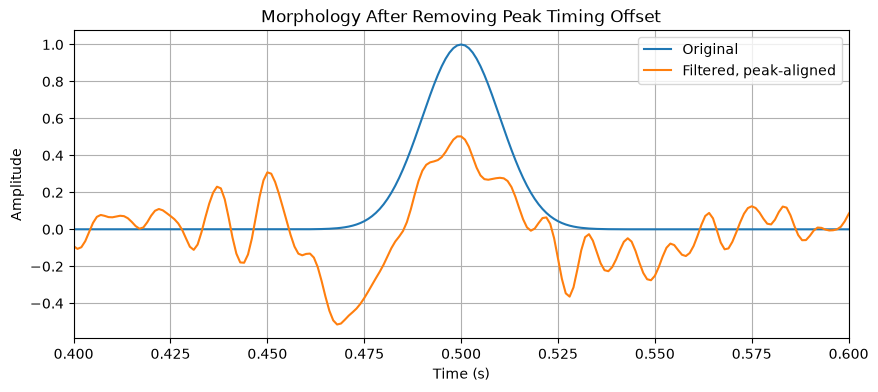

In [24]:
plt.figure(figsize=(10, 4))

plt.plot(t, event, label="Original")
plt.plot(t_filtered_aligned, event_filtered, label="Filtered, peak-aligned")

plt.xlim(0.4, 0.6)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Morphology After Removing Peak Timing Offset")
plt.legend()
plt.grid()
plt.show()

In [25]:
delay_samples = peak_filtered - peak_original

event_filtered_aligned = np.roll(
    event_filtered,
    -delay_samples
)

valid = (t >= 0.4) & (t <= 0.6)

original_segment = event[valid]
filtered_segment = event_filtered_aligned[valid]

rmse = np.sqrt(np.mean((original_segment - filtered_segment)**2))

print(f"RMSE: {rmse:.2f}")

RMSE: 0.24


In [26]:
correlation = np.corrcoef(
    original_segment,
    filtered_segment
)[0, 1]

print("Correlation:", correlation)

Correlation: 0.6547093674960792


In [27]:
noise_levels = [0.05, 0.1, 0.2, 0.4, 0.8]

results = []

for noise_std in noise_levels:

    np.random.seed(42)

    noise = noise_std * np.random.randn(len(t))
    event_noisy = event + noise

    # Causal filtering
    event_filtered = signal.lfilter(
        b_band,
        a_band,
        event_noisy
    )

    # Find peak
    peak_filtered = np.argmax(event_filtered)

    timing_error_ms = (
        (peak_filtered - peak_original) / fs * 1000
    )

    # Align using peak
    delay_samples = peak_filtered - peak_original

    event_filtered_aligned = np.roll(
        event_filtered,
        -delay_samples
    )

    # Compare only central region
    valid = (t >= 0.4) & (t <= 0.6)

    original_segment = event[valid]
    filtered_segment = event_filtered_aligned[valid]

    rmse = np.sqrt(
        np.mean(
            (original_segment - filtered_segment)**2
        )
    )

    correlation = np.corrcoef(
        original_segment,
        filtered_segment
    )[0, 1]

    results.append(
        [noise_std, timing_error_ms, rmse, correlation]
    )

In [28]:
for result in results:
    print(
        f"Noise={result[0]:.2f}, "
        f"Timing={result[1]:.2f} ms, "
        f"RMSE={result[2]:.3f}, "
        f"Correlation={result[3]:.3f}"
    )

Noise=0.05, Timing=43.00 ms, RMSE=0.238, Correlation=0.662
Noise=0.10, Timing=43.00 ms, RMSE=0.238, Correlation=0.666
Noise=0.20, Timing=44.00 ms, RMSE=0.242, Correlation=0.655
Noise=0.40, Timing=44.00 ms, RMSE=0.275, Correlation=0.580
Noise=0.80, Timing=155.00 ms, RMSE=0.410, Correlation=0.262


In [29]:
for noise_std in noise_levels:

    signal_power = np.mean(event**2)
    noise_power = noise_std**2

    snr_db = 10 * np.log10(
        signal_power / noise_power
    )

    print(
        f"Noise={noise_std:.2f}, "
        f"SNR={snr_db:.2f} dB"
    )

Noise=0.05, SNR=8.51 dB
Noise=0.10, SNR=2.49 dB
Noise=0.20, SNR=-3.53 dB
Noise=0.40, SNR=-9.56 dB
Noise=0.80, SNR=-15.58 dB


In [30]:
fs = 1000
t = np.arange(0, 1, 1/fs)

event = np.exp(
    -0.5 * ((t - 0.5) / 0.01)**2
)

artifact = 2.0 * np.exp(
    -0.5 * ((t - 0.6) / 0.003)**2
)

np.random.seed(42)
noise = 0.1 * np.random.randn(len(t))

x_artifact = event + artifact + noise

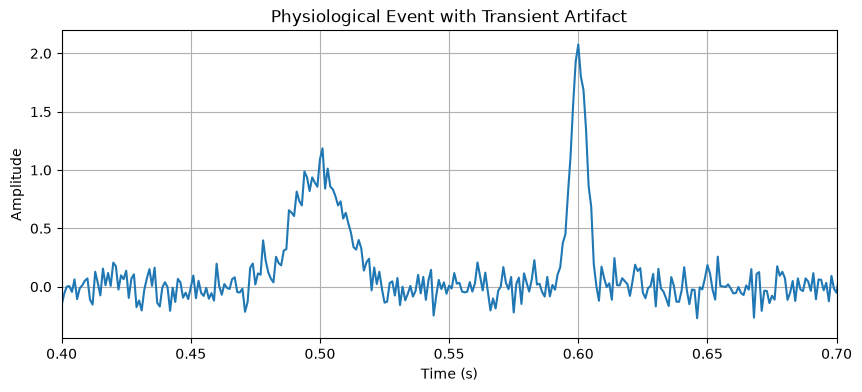

In [31]:
plt.figure(figsize=(10, 4))

plt.plot(t, x_artifact)

plt.xlim(0.4, 0.7)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Physiological Event with Transient Artifact")
plt.grid()
plt.show()

In [32]:
y_filtered = signal.lfilter(
    b_band,
    a_band,
    x_artifact
)

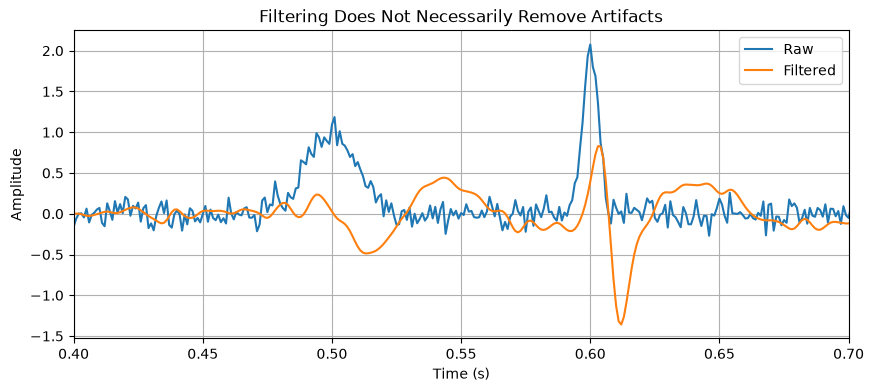

In [33]:
plt.figure(figsize=(10, 4))

plt.plot(t, x_artifact, label="Raw")
plt.plot(t, y_filtered, label="Filtered")

plt.xlim(0.4, 0.7)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Filtering Does Not Necessarily Remove Artifacts")
plt.legend()
plt.grid()
plt.show()

In [34]:
baseline_region = (t < 0.4)

baseline = y_filtered[baseline_region]

baseline_mean = np.mean(baseline)
baseline_std = np.std(baseline)

threshold = baseline_mean + 5 * baseline_std

print("Baseline mean:", baseline_mean)
print("Baseline std:", baseline_std)
print("Artifact threshold:", threshold)

Baseline mean: -0.00033392963911111506
Baseline std: 0.03890949459446776
Artifact threshold: 0.1942135433332277


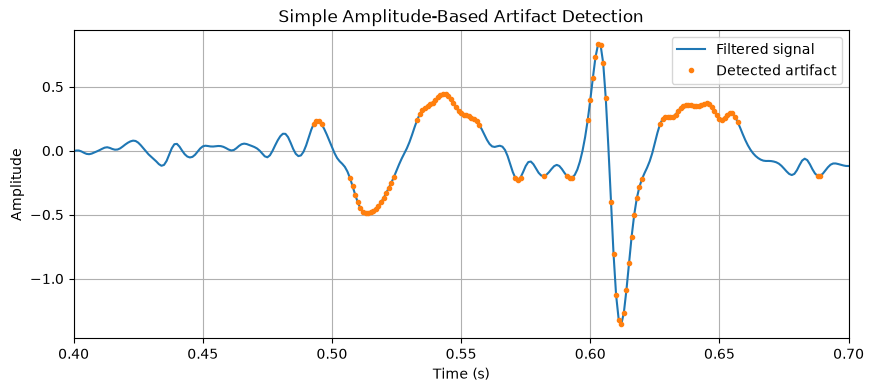

In [35]:
artifact_mask = np.abs(y_filtered - baseline_mean) > 5 * baseline_std
plt.figure(figsize=(10, 4))

plt.plot(t, y_filtered, label="Filtered signal")
plt.plot(
    t[artifact_mask],
    y_filtered[artifact_mask],
    ".",
    label="Detected artifact"
)

plt.xlim(0.4, 0.7)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Simple Amplitude-Based Artifact Detection")
plt.legend()
plt.grid()
plt.show()

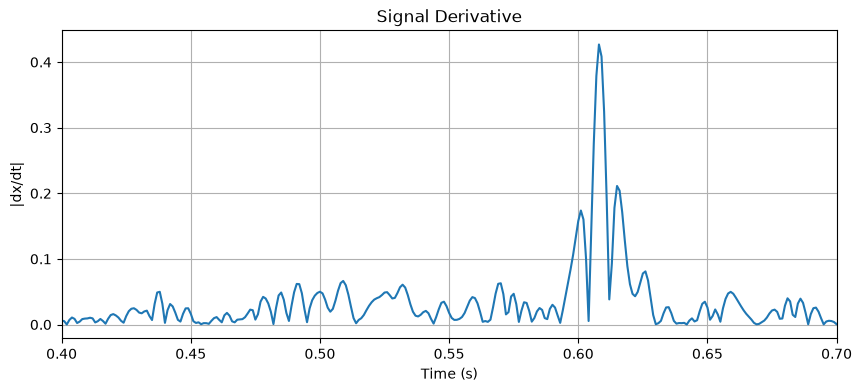

In [36]:
derivative = np.diff(y_filtered)

plt.figure(figsize=(10, 4))
plt.plot(t[1:], np.abs(derivative))
plt.xlim(0.4, 0.7)
plt.xlabel("Time (s)")
plt.ylabel("|dx/dt|")
plt.title("Signal Derivative")
plt.grid()
plt.show()

In [37]:
artifact_truth = (
    (t >= 0.59) &
    (t <= 0.61)
)

true_positive = np.sum(
    artifact_mask & artifact_truth
)

false_positive = np.sum(
    artifact_mask & ~artifact_truth
)

true_negative = np.sum(
    ~artifact_mask & ~artifact_truth
)

false_negative = np.sum(
    ~artifact_mask & artifact_truth
)

sensitivity = (
    true_positive /
    (true_positive + false_negative)
)

print("Sensitivity:", sensitivity)

specificity = (
    true_negative /
    (true_negative + false_positive)
)

print("Specificity:", specificity)

precision = (
    true_positive /
    (true_positive + false_positive)
)

print("Precision:", precision)

Sensitivity: 0.6666666666666666
Specificity: 0.9039836567926456
Precision: 0.12962962962962962


In [38]:
threshold_multipliers = np.linspace(1, 8, 50)

sensitivities = []
specificities = []
precisions = []

for k in threshold_multipliers:

    artifact_mask_k = (
        np.abs(y_filtered - baseline_mean)
        > k * baseline_std
    )

    tp = np.sum(artifact_mask_k & artifact_truth)
    fp = np.sum(artifact_mask_k & ~artifact_truth)
    tn = np.sum(~artifact_mask_k & ~artifact_truth)
    fn = np.sum(~artifact_mask_k & artifact_truth)

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan

    sensitivities.append(sensitivity)
    specificities.append(specificity)
    precisions.append(precision)

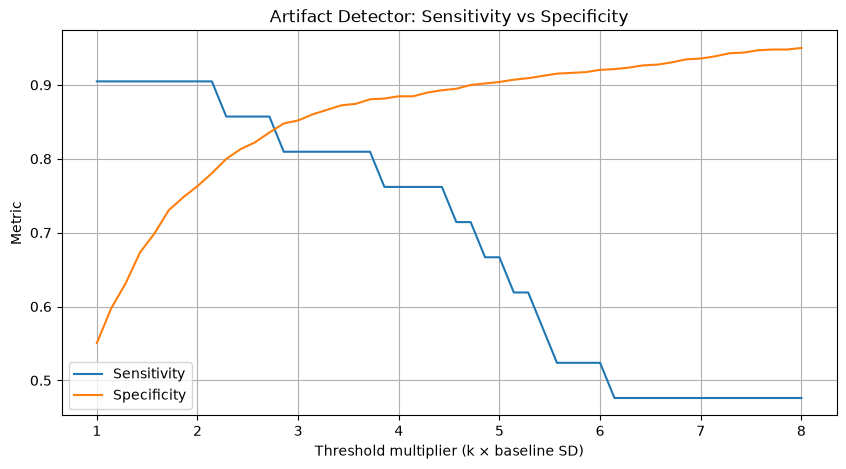

In [39]:
plt.figure(figsize=(10, 5))

plt.plot(threshold_multipliers, sensitivities, label="Sensitivity")
plt.plot(threshold_multipliers, specificities, label="Specificity")
plt.xlabel("Threshold multiplier (k × baseline SD)")
plt.ylabel("Metric")
plt.title("Artifact Detector: Sensitivity vs Specificity")
plt.grid(True)
plt.legend()
plt.show()

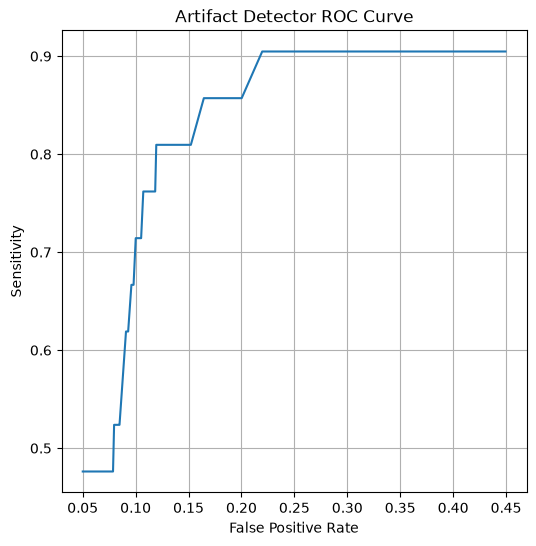

In [40]:
false_positive_rates = [
    1 - s for s in specificities
]

plt.figure(figsize=(6, 6))

plt.plot(false_positive_rates, sensitivities)

plt.xlabel("False Positive Rate")
plt.ylabel("Sensitivity")
plt.title("Artifact Detector ROC Curve")
plt.grid(True)
plt.show()

In [41]:
fs = 1000
t = np.arange(0, 1, 1/fs)

event = np.exp(-0.5*((t-0.5)/0.01)**2)

np.random.seed(42)

noise_low = 0.1 * np.random.randn(len(t)//2)
noise_high = 0.4 * np.random.randn(len(t) - len(t)//2)

noise_variable = np.concatenate([noise_low, noise_high])

x_variable = event + noise_variable

In [42]:
artifact = 1.5 * np.exp(-0.5*((t-0.75)/0.005)**2)

x_variable = x_variable + artifact

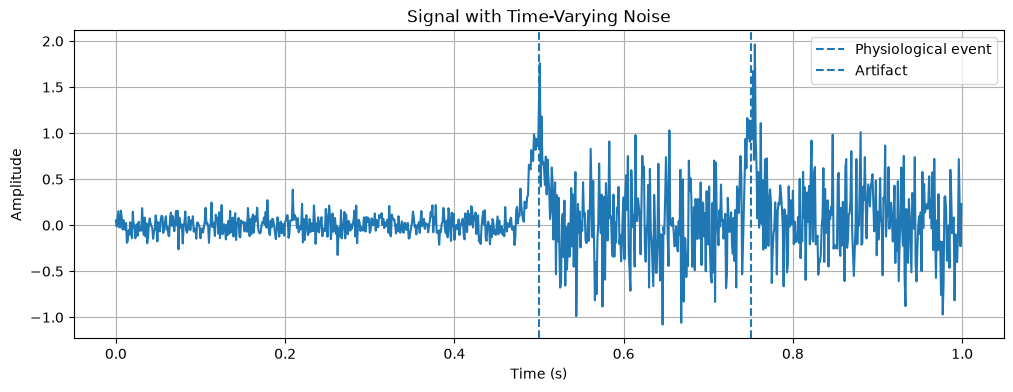

In [43]:
plt.figure(figsize=(12, 4))

plt.plot(t, x_variable)
plt.axvline(0.5, linestyle="--", label="Physiological event")
plt.axvline(0.75, linestyle="--", label="Artifact")

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Signal with Time-Varying Noise")
plt.grid(True)
plt.legend()
plt.show()

In [44]:
baseline_region = t < 0.4

fixed_mean = np.mean(x_variable[baseline_region])
fixed_std = np.std(x_variable[baseline_region])

fixed_threshold = fixed_mean + 5 * fixed_std

In [45]:
window_size = 100

rolling_mean = np.zeros(len(x_variable))
rolling_std = np.zeros(len(x_variable))

for i in range(len(x_variable)):

    start = max(0, i - window_size)
    end = min(len(x_variable), i + window_size)

    window = x_variable[start:end]

    rolling_mean[i] = np.mean(window)
    rolling_std[i] = np.std(window)

adaptive_threshold = rolling_mean + 5 * rolling_std

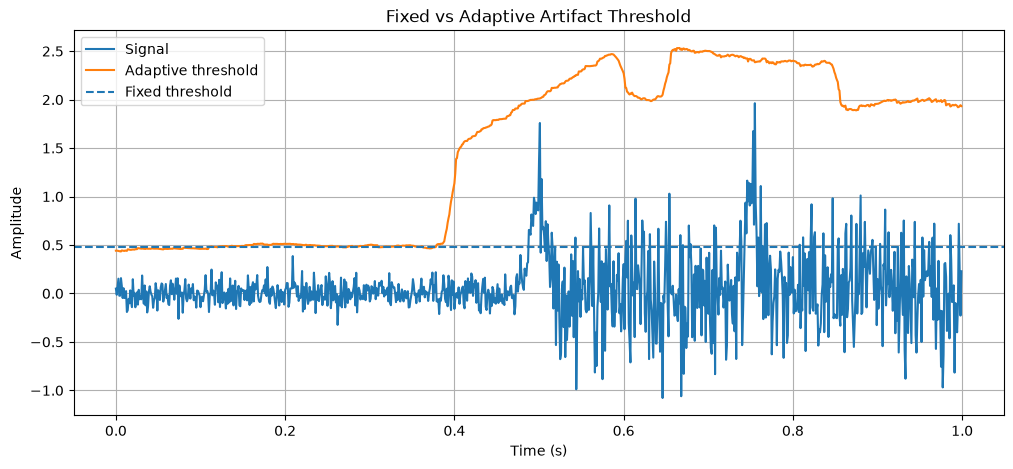

In [46]:
plt.figure(figsize=(12, 5))

plt.plot(t, x_variable, label="Signal")
plt.plot(t, adaptive_threshold, label="Adaptive threshold")
plt.axhline(fixed_threshold, linestyle="--", label="Fixed threshold")

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Fixed vs Adaptive Artifact Threshold")
plt.grid(True)
plt.legend()
plt.show()

In [47]:
window_size = 200

rolling_median = np.zeros(len(x_variable))
rolling_mad = np.zeros(len(x_variable))

for i in range(len(x_variable)):

    start = max(0, i - window_size)
    window = x_variable[start:i]

    if len(window) < 20:
        rolling_median[i] = np.median(x_variable[:i+1])
        rolling_mad[i] = np.median(
            np.abs(x_variable[:i+1] - rolling_median[i])
        )
    else:
        rolling_median[i] = np.median(window)
        rolling_mad[i] = np.median(
            np.abs(window - rolling_median[i])
        )

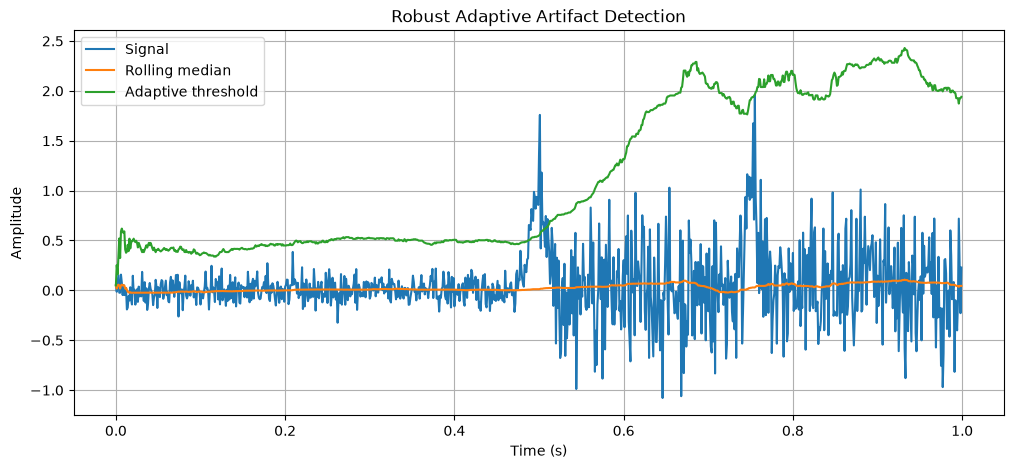

In [48]:
robust_sigma = 1.4826 * rolling_mad

k = 5

adaptive_threshold = (
    rolling_median +
    k * robust_sigma
)

artifact_mask = (
    np.abs(x_variable - rolling_median)
    > k * robust_sigma
)

plt.figure(figsize=(12, 5))

plt.plot(t, x_variable, label="Signal")
plt.plot(t, rolling_median, label="Rolling median")
plt.plot(t, adaptive_threshold, label="Adaptive threshold")

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Robust Adaptive Artifact Detection")
plt.grid(True)
plt.legend()
plt.show()

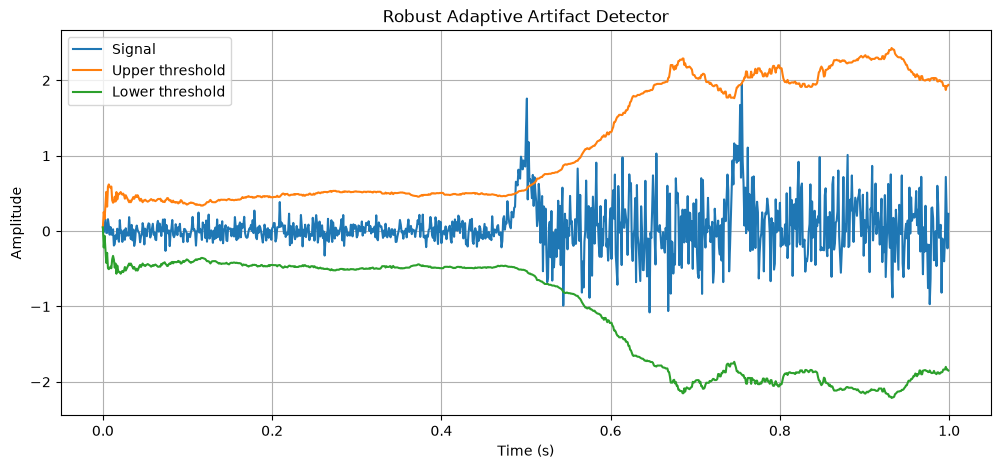

In [49]:
lower_threshold = rolling_median - k * robust_sigma

plt.figure(figsize=(12, 5))

plt.plot(t, x_variable, label="Signal")
plt.plot(t, adaptive_threshold, label="Upper threshold")
plt.plot(t, lower_threshold, label="Lower threshold")

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Robust Adaptive Artifact Detector")
plt.grid(True)
plt.legend()
plt.show()

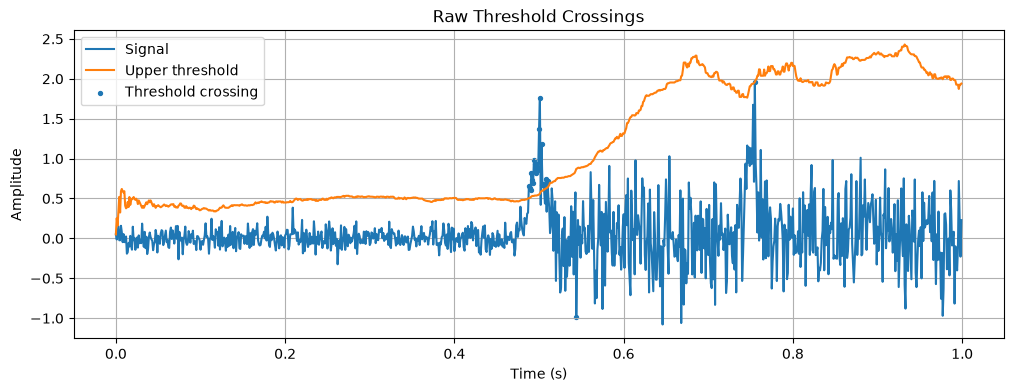

In [50]:
artifact_candidate = (
    np.abs(x_variable - rolling_median)
    > 5 * robust_sigma
)

plt.figure(figsize=(12, 4))

plt.plot(t, x_variable, label="Signal")
plt.plot(t, adaptive_threshold, label="Upper threshold")

plt.scatter(
    t[artifact_candidate],
    x_variable[artifact_candidate],
    s=8,
    label="Threshold crossing"
)

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Raw Threshold Crossings")
plt.grid(True)
plt.legend()
plt.show()

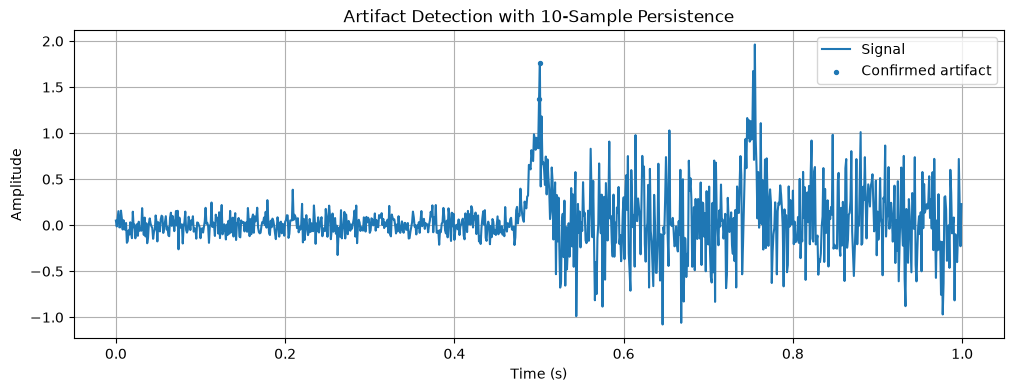

In [52]:
min_samples = 10

artifact_event = np.zeros(len(artifact_candidate), dtype=bool)

run_length = 0

for i, is_above in enumerate(artifact_candidate):

    if is_above:
        run_length += 1
    else:
        run_length = 0

    if run_length >= min_samples:
        artifact_event[i] = True

plt.figure(figsize=(12, 4))

plt.plot(t, x_variable, label="Signal")

plt.scatter(
    t[artifact_event],
    x_variable[artifact_event],
    s=8,
    label="Confirmed artifact"
)

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Artifact Detection with 10-Sample Persistence")
plt.grid(True)
plt.legend()
plt.show()

In [53]:
artifact_start = 0.75

detected_indices = np.where(artifact_event)[0]

first_detection = detected_indices[0]

detection_time = t[first_detection]

latency_ms = (
    detection_time - artifact_start
) * 1000

print(f"Detection time: {detection_time:.4f} s")
print(f"Detection latency: {latency_ms:.2f} ms")

Detection time: 0.4970 s
Detection latency: -253.00 ms


In [54]:
min_samples_values = [1, 3, 5, 10, 20, 50]

latencies = []

for min_samples in min_samples_values:

    artifact_event = np.zeros(len(artifact_candidate), dtype=bool)

    run_length = 0

    for i, is_above in enumerate(artifact_candidate):

        if is_above:
            run_length += 1
        else:
            run_length = 0

        if run_length >= min_samples:
            artifact_event[i] = True

    detected_indices = np.where(artifact_event)[0]

    if len(detected_indices) > 0:
        latency = (
            t[detected_indices[0]]
            - artifact_start
        ) * 1000
    else:
        latency = np.nan

    latencies.append(latency)

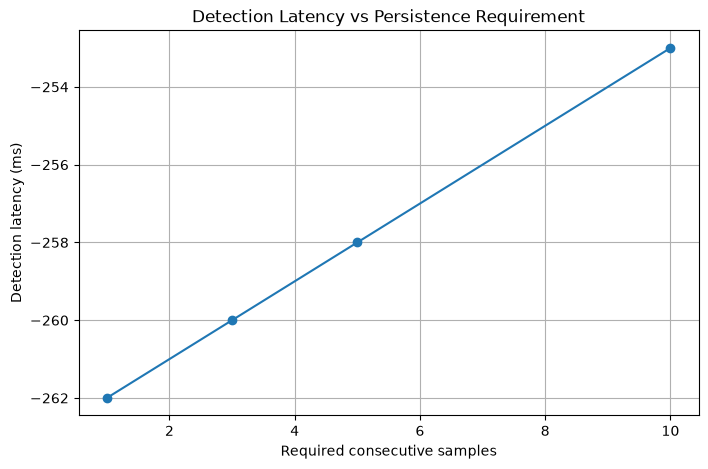

In [55]:
plt.figure(figsize=(8, 5))

plt.plot(
    min_samples_values,
    latencies,
    marker="o"
)

plt.xlabel("Required consecutive samples")
plt.ylabel("Detection latency (ms)")
plt.title("Detection Latency vs Persistence Requirement")
plt.grid(True)
plt.show()

In [56]:
window_size = 20
derivative = np.diff(x_variable)
derivative = np.concatenate([[0], derivative])

amplitude_feature = np.zeros(len(x_variable))
slope_feature = np.zeros(len(x_variable))
energy_feature = np.zeros(len(x_variable))

for i in range(len(x_variable)):

    start = max(0, i - window_size)

    window = x_variable[start:i+1]
    derivative_window = derivative[start:i+1]

    amplitude_feature[i] = np.max(np.abs(window))

    slope_feature[i] = np.max(
        np.abs(derivative_window)
    )

    energy_feature[i] = np.sqrt(
        np.mean(window**2)
    )

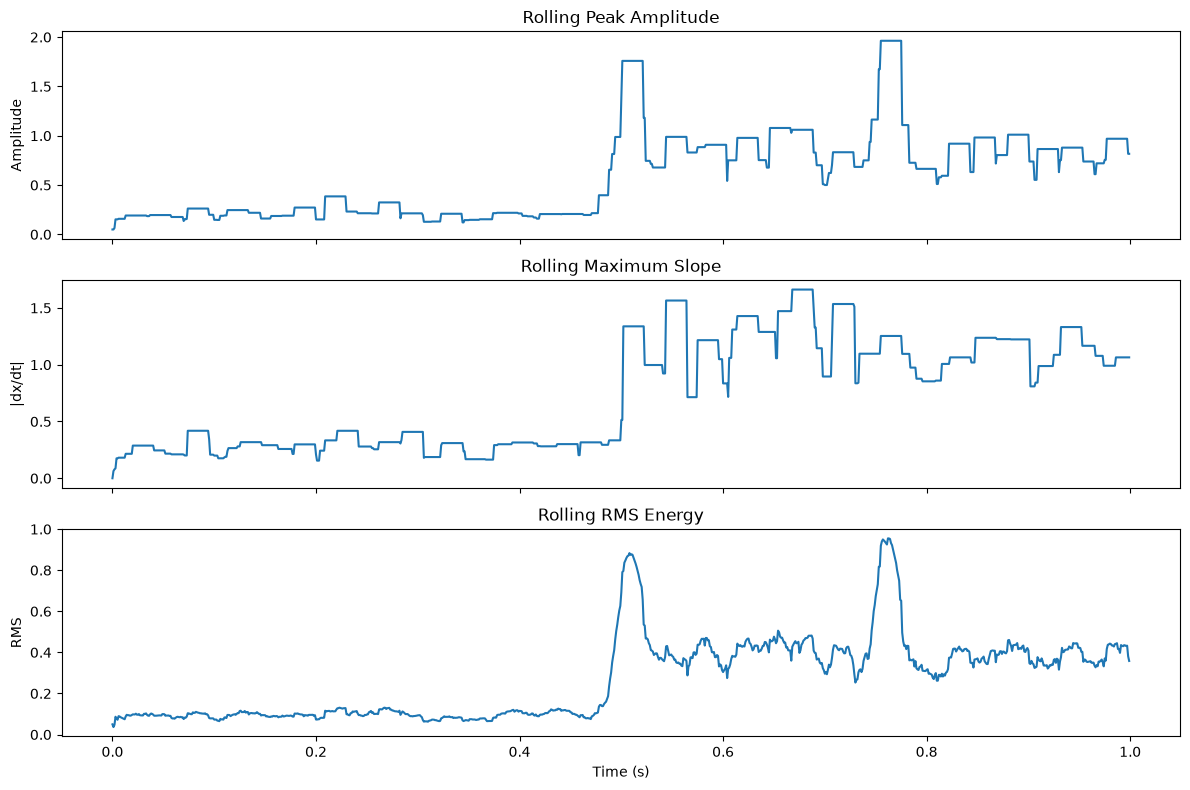

In [57]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(t, amplitude_feature)
axes[0].set_ylabel("Amplitude")
axes[0].set_title("Rolling Peak Amplitude")

axes[1].plot(t, slope_feature)
axes[1].set_ylabel("|dx/dt|")
axes[1].set_title("Rolling Maximum Slope")

axes[2].plot(t, energy_feature)
axes[2].set_ylabel("RMS")
axes[2].set_xlabel("Time (s)")
axes[2].set_title("Rolling RMS Energy")

plt.tight_layout()
plt.show()

In [58]:
window_size = 20

features = []
labels = []

for start in range(0, len(x_variable) - window_size, window_size):

    end = start + window_size

    window = x_variable[start:end]
    derivative_window = derivative[start:end]

    amplitude = np.max(np.abs(window))

    slope = np.max(np.abs(derivative_window))

    energy = np.sqrt(np.mean(window**2))

    features.append([
        amplitude,
        slope,
        energy
    ])

    # Label window as artifact if its center is inside artifact interval
    center_time = t[start + window_size // 2]

    label = (
        1 if 0.74 <= center_time <= 0.76
        else 0
    )

    labels.append(label)

features = np.array(features)
labels = np.array(labels)

In [59]:
artifact_features = features[labels == 1]
normal_features = features[labels == 0]
print("Normal mean:")
print(np.mean(normal_features, axis=0))

print("\nArtifact mean:")
print(np.mean(artifact_features, axis=0))

Normal mean:
[0.56247783 0.72255424 0.25593172]

Artifact mean:
[1.96274882 1.25328482 0.95463242]


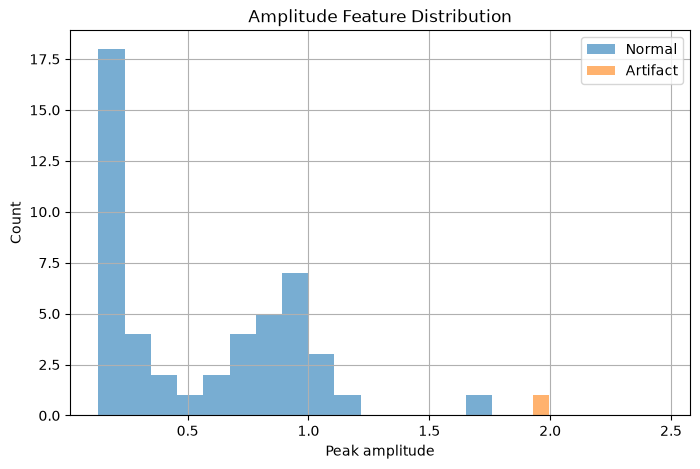

In [60]:
plt.figure(figsize=(8, 5))

plt.hist(
    normal_features[:, 0],
    bins=15,
    alpha=0.6,
    label="Normal"
)

plt.hist(
    artifact_features[:, 0],
    bins=15,
    alpha=0.6,
    label="Artifact"
)

plt.xlabel("Peak amplitude")
plt.ylabel("Count")
plt.title("Amplitude Feature Distribution")
plt.legend()
plt.grid(True)
plt.show()

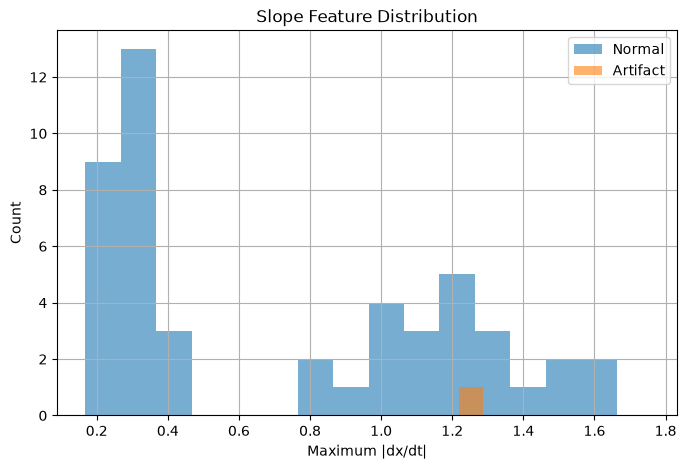

In [61]:
plt.figure(figsize=(8, 5))

plt.hist(
    normal_features[:, 1],
    bins=15,
    alpha=0.6,
    label="Normal"
)

plt.hist(
    artifact_features[:, 1],
    bins=15,
    alpha=0.6,
    label="Artifact"
)

plt.xlabel("Maximum |dx/dt|")
plt.ylabel("Count")
plt.title("Slope Feature Distribution")
plt.legend()
plt.grid(True)
plt.show()

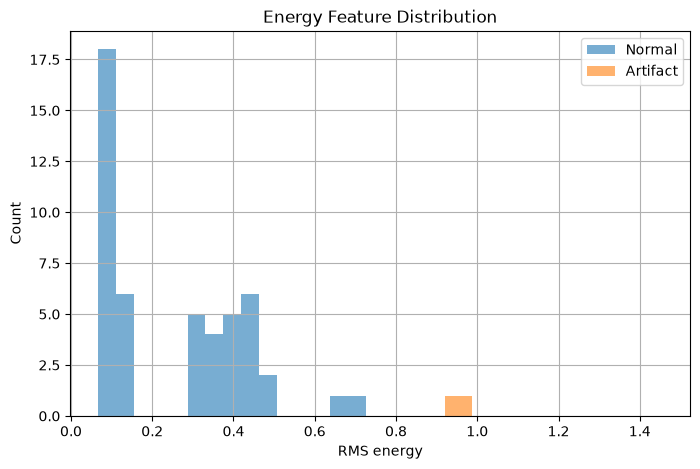

In [62]:
plt.figure(figsize=(8, 5))

plt.hist(
    normal_features[:, 2],
    bins=15,
    alpha=0.6,
    label="Normal"
)

plt.hist(
    artifact_features[:, 2],
    bins=15,
    alpha=0.6,
    label="Artifact"
)

plt.xlabel("RMS energy")
plt.ylabel("Count")
plt.title("Energy Feature Distribution")
plt.legend()
plt.grid(True)
plt.show()

In [63]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(features, labels)

predictions = model.predict(features)

accuracy = np.mean(predictions == labels)

print(f"Training accuracy: {accuracy:.3f}")

Training accuracy: 0.980


In [64]:
np.random.seed(42)

n_subjects = 5
samples_per_subject = 1000

all_features = []
all_labels = []
all_subjects = []

for subject in range(n_subjects):

    # Give each subject a different noise level
    noise_std = 0.08 + 0.04 * subject

    signal = noise_std * np.random.randn(samples_per_subject)

    # Add several physiological events
    event_times = [0.3, 0.6]

    for event_time in event_times:
        center = int(event_time * samples_per_subject)

        start = max(0, center - 10)
        end = min(samples_per_subject, center + 10)

        signal[start:end] += np.exp(
            -0.5 * ((np.arange(start, end) - center) / 4)**2
        )

    # Add artifact
    artifact_center = int(0.8 * samples_per_subject)

    start = artifact_center - 5
    end = artifact_center + 5

    signal[start:end] += 1.5

    derivative = np.diff(signal)
    derivative = np.concatenate([[0], derivative])

    # Create windows
    window_size = 20

    for start in range(
        0,
        len(signal) - window_size,
        window_size
    ):

        end = start + window_size

        window = signal[start:end]
        derivative_window = derivative[start:end]

        amplitude = np.max(np.abs(window))
        slope = np.max(np.abs(derivative_window))
        energy = np.sqrt(np.mean(window**2))

        all_features.append([
            amplitude,
            slope,
            energy
        ])

        center_time = (
            start + window_size / 2
        ) / samples_per_subject

        label = (
            1
            if 0.79 <= center_time <= 0.81
            else 0
        )

        all_labels.append(label)
        all_subjects.append(subject)

X = np.array(all_features)
y = np.array(all_labels)
subjects = np.array(all_subjects)

In [65]:
test_subject = 4

train_mask = subjects != test_subject
test_mask = subjects == test_subject

X_train = X[train_mask]
y_train = y[train_mask]

X_test = X[test_mask]
y_test = y[test_mask]

from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)


from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        47
           1       1.00      1.00      1.00         2

    accuracy                           1.00        49
   macro avg       1.00      1.00      1.00        49
weighted avg       1.00      1.00      1.00        49



In [66]:
from sklearn.metrics import accuracy_score

loso_results = []

for test_subject in np.unique(subjects):

    train_mask = subjects != test_subject
    test_mask = subjects == test_subject

    X_train = X[train_mask]
    y_train = y[train_mask]

    X_test = X[test_mask]
    y_test = y[test_mask]

    model = LogisticRegression()

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    loso_results.append(accuracy)

print(loso_results)
print("Mean LOSO accuracy:", np.mean(loso_results))

[1.0, 1.0, 1.0, 0.9795918367346939, 1.0]
Mean LOSO accuracy: 0.9959183673469388


In [67]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression())
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,3
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [68]:
from sklearn.metrics import accuracy_score

loso_results = []

for test_subject in np.unique(subjects):

    train_mask = subjects != test_subject
    test_mask = subjects == test_subject

    X_train = X[train_mask]
    y_train = y[train_mask]

    X_test = X[test_mask]
    y_test = y[test_mask]

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression())
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    loso_results.append(accuracy)

print(loso_results)
print("Mean LOSO accuracy:", np.mean(loso_results))

[1.0, 1.0, 1.0, 1.0, 1.0]
Mean LOSO accuracy: 1.0


In [69]:
noise_levels = [0.05, 0.1, 0.2, 0.4, 0.8]
artifact_amplitudes = [0.5, 1.0, 1.5, 2.0]
artifact_durations_ms = [2, 5, 10, 20]

In [70]:
fs = 1000
duration = 1.0

t = np.arange(0, duration, 1/fs)

artifact_start = 0.75

In [71]:
def create_test_signal(
    noise_std,
    artifact_amplitude,
    artifact_duration_ms
):

    signal_clean = np.zeros(len(t))

    noise = noise_std * np.random.randn(len(t))

    x = signal_clean + noise

    artifact_samples = int(
        artifact_duration_ms * fs / 1000
    )

    start_idx = int(
        artifact_start * fs
    )

    end_idx = start_idx + artifact_samples

    x[start_idx:end_idx] += artifact_amplitude

    truth = np.zeros(len(t), dtype=bool)
    truth[start_idx:end_idx] = True

    return x, truth

In [72]:
def detect_artifact(x, threshold_multiplier=5):

    baseline = x[t < 0.4]

    baseline_mean = np.mean(baseline)
    baseline_std = np.std(baseline)

    threshold = (
        baseline_mean
        + threshold_multiplier * baseline_std
    )

    detected = (
        np.abs(x - baseline_mean)
        > threshold_multiplier * baseline_std
    )

    return detected

In [73]:
x, truth = create_test_signal(
    noise_std=0.2,
    artifact_amplitude=1.5,
    artifact_duration_ms=10
)

detected = detect_artifact(x)

In [74]:
tp = np.sum(detected & truth)
fp = np.sum(detected & ~truth)

tn = np.sum(~detected & ~truth)
fn = np.sum(~detected & truth)

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

Sensitivity: 1.0
Specificity: 1.0


In [75]:
results = []

for noise_std in noise_levels:

    for amplitude in artifact_amplitudes:

        for duration_ms in artifact_durations_ms:

            x, truth = create_test_signal(
                noise_std,
                amplitude,
                duration_ms
            )

            detected = detect_artifact(x)

            tp = np.sum(detected & truth)
            fp = np.sum(detected & ~truth)

            tn = np.sum(~detected & ~truth)
            fn = np.sum(~detected & truth)

            sensitivity = (
                tp / (tp + fn)
                if (tp + fn) > 0
                else np.nan
            )

            specificity = (
                tn / (tn + fp)
                if (tn + fp) > 0
                else np.nan
            )

            results.append({
                "noise": noise_std,
                "amplitude": amplitude,
                "duration_ms": duration_ms,
                "sensitivity": sensitivity,
                "specificity": specificity
            })

In [77]:
import pandas as pd

results_df = pd.DataFrame(results)

results_df

,noise,amplitude,duration_ms,sensitivity,specificity
0,0.05,0.5,2,1.0,1.0
1,0.05,0.5,5,1.0,1.0
2,0.05,0.5,10,1.0,1.0
3,0.05,0.5,20,1.0,1.0
4,0.05,1.0,2,1.0,1.0
...,...,...,...,...,...
75,0.80,1.5,20,0.0,1.0
76,0.80,2.0,2,0.0,1.0
77,0.80,2.0,5,0.0,1.0
78,0.80,2.0,10,0.0,1.0


In [78]:
duration_ms = 10

sensitivity_matrix = np.zeros(
    (len(noise_levels), len(artifact_amplitudes))
)

for i, noise_std in enumerate(noise_levels):

    for j, amplitude in enumerate(artifact_amplitudes):

        x, truth = create_test_signal(
            noise_std,
            amplitude,
            duration_ms
        )

        detected = detect_artifact(x)

        tp = np.sum(detected & truth)
        fn = np.sum(~detected & truth)

        sensitivity_matrix[i, j] = (
            tp / (tp + fn)
            if (tp + fn) > 0
            else np.nan
        )

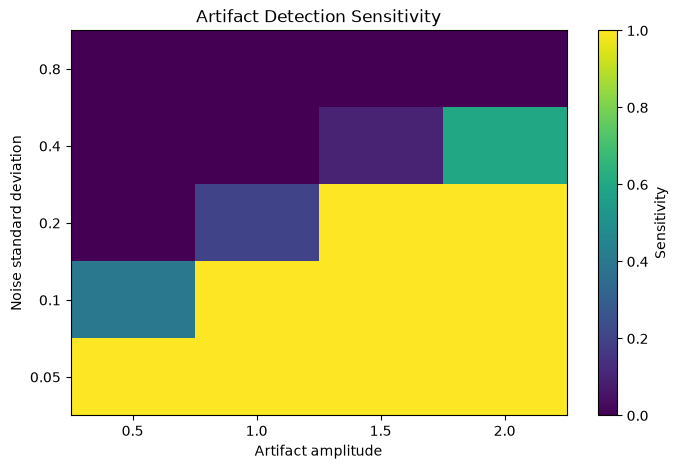

In [79]:
plt.figure(figsize=(8, 5))

plt.imshow(
    sensitivity_matrix,
    origin="lower",
    aspect="auto"
)

plt.xticks(
    range(len(artifact_amplitudes)),
    artifact_amplitudes
)

plt.yticks(
    range(len(noise_levels)),
    noise_levels
)

plt.xlabel("Artifact amplitude")
plt.ylabel("Noise standard deviation")
plt.title("Artifact Detection Sensitivity")

plt.colorbar(label="Sensitivity")

plt.show()